In [1]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from medmnist import PneumoniaMNIST

In [3]:
def load_data():
    train = PneumoniaMNIST(split="train", download=True)
    val = PneumoniaMNIST(split="val", download=True)
    test = PneumoniaMNIST(split="test", download=True)

    return (
        train.imgs, train.labels.flatten(),
        val.imgs, val.labels.flatten(),
        test.imgs, test.labels.flatten()
    )

In [4]:
def show_eda(X, y):
    count = np.bincount(y)
    print("Total Images :", len(X))
    print("Image Shape  :", X.shape[1:])
    print("Classes      :", len(np.unique(y)))
    print("\nClass Distribution:")

    for i, value in enumerate(count):
        print("Class", i, ":", value)

    plt.figure(figsize=(7, 4))
    plt.bar(range(len(count)), count)
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.title("RetinaMNIST Class Distribution")
    plt.xticks([0, 1], ["Normal", "Pneumonia"])
    plt.grid(axis="y")
    plt.show()

In [5]:
def preprocess(X_train, y_train, X_val, y_val, X_test, y_test):
    original_shape = X_train.shape[1:]

    X_train = X_train.astype("float32") / 255.0
    X_val = X_val.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0

    X_train = X_train.reshape(len(X_train), -1)
    X_val = X_val.reshape(len(X_val), -1)
    X_test = X_test.reshape(len(X_test), -1)

    print("\nSTEP 4: PREPROCESSING / STANDARDIZATION")
    print("Original Image Size :", original_shape)
    print("Flattened Size      :", X_train.shape[1])
    print("Pixel Range         :", X_train.min(), "to", X_train.max())

    print("\nSTEP 5: DATA SPLIT")
    print("Training Samples   :", len(X_train))
    print("Validation Samples :", len(X_val))
    print("Testing Samples    :", len(X_test))

    return X_train, X_val, X_test, y_train, y_val, y_test

In [6]:
def create_model(input_size, classes, regularizer=None, dropout=0, learning_rate=0.001):
    model = Sequential([
        Input(shape=(input_size,)),
        # Dense(512, activation="relu", kernel_regularizer=regularizer),
        # Dense(256, activation="relu", kernel_regularizer=regularizer),
        Dense(128, activation="relu", kernel_regularizer=regularizer),
        Dense(64, activation="relu", kernel_regularizer=regularizer),
        Dropout(dropout),
        Dense(2, activation="softmax")
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    model.summary(line_length=60,positions=[0.3, 0.6, 0.75, 1.0])
    return model

In [7]:
def train_regularizers(X_train, y_train, X_val, y_val, X_test, y_test, input_size, classes):
    techniques = {
        "Baseline": (None, 0),
        "L1": (l1(0.0001), 0),
        "L2": (l2(0.0001), 0),
        "Dropout": (None, 0.5)
    }

    models = {}
    histories = {}
    results = []
    for name, (regularizer, dropout) in techniques.items():
        print("\nTraining:", name)
        model = create_model(input_size, classes, regularizer, dropout)
        history = model.fit(X_train, y_train,validation_data=(X_val, y_val),
            epochs=10,batch_size=128,verbose=0)
        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
        models[name] = model
        histories[name] = history
        results.append([name, accuracy * 100, loss])
        print("Test Accuracy:", round(accuracy * 100, 2), "%")

    return models, histories, results

In [8]:
def train_early_stopping(X_train, y_train, X_val, y_val, X_test, y_test, input_size, classes):
    print("\nTraining: Early Stopping")
    model = create_model(input_size, classes)
    early_stop = EarlyStopping(monitor="val_loss",patience=3,
                          restore_best_weights=True)
    history = model.fit(X_train, y_train,validation_data=(X_val, y_val),
        epochs=10,batch_size=128,callbacks=[early_stop],verbose=0)
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print("Test Accuracy:", round(accuracy * 100, 2), "%")
    print("Epochs Trained:", len(history.history["loss"]))
    return model, history, accuracy, loss

In [9]:
def show_results(results):
    df = pd.DataFrame(results,columns=["Technique", "Accuracy (%)", "Loss"])
    print("REGULARIZATION PERFORMANCE COMPARISON")
    print(df.to_string(index=False))
    return df

In [10]:
def plot_graphs(histories):
    metrics = [
        ("accuracy", "Training Accuracy"),
        ("val_accuracy", "Validation Accuracy"),
        ("loss", "Training Loss"),
        ("val_loss", "Validation Loss")
    ]
    plt.figure(figsize=(12, 8))
    for i, (metric, title) in enumerate(metrics, 1):
        plt.subplot(2, 2, i)
        for name, history in histories.items():
            plt.plot(history.history[metric], marker="o", label=name)
        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy" if "accuracy" in metric else "Loss")
        plt.legend()
        plt.grid()
    plt.tight_layout()
    plt.show()

In [11]:
def accuracy_graph(df):
    plt.figure(figsize=(8, 5))
    plt.bar(df["Technique"], df["Accuracy (%)"])
    plt.xlabel("Technique")
    plt.ylabel("Accuracy (%)")
    plt.title("RetinaMNIST Regularization Comparison")
    plt.ylim(0, 100)
    plt.grid(axis="y")

    for i, value in enumerate(df["Accuracy (%)"]):
        plt.text(i, value + 0.3, f"{value:.2f}%", ha="center")

    plt.tight_layout()
    plt.show()

In [12]:
def hyperparameter_tuning(X_train, y_train, X_val, y_val, X_test, y_test, input_size, classes):
    parameters = [
        (0.2, 0.0001, 0.001),
        (0.3, 0.0001, 0.001),
        (0.5, 0.0001, 0.001),
        (0.3, 0.001, 0.001),
        (0.5, 0.001, 0.001),
        (0.3, 0.001, 0.0005)
    ]
    results = []
    for dropout, l2_value, lr in parameters:
        print("\nDropout:", dropout, "| L2:", l2_value, "| LR:", lr)
        model = create_model(input_size,classes,regularizer=l2(l2_value),
                             dropout=dropout,learning_rate=lr)
        model.fit(X_train, y_train,validation_data=(X_val, y_val),
                  epochs=10,batch_size=64,verbose=0)
        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
        results.append([dropout,l2_value,lr,accuracy * 100])
        print("Accuracy:", round(accuracy * 100, 2), "%")
    return pd.DataFrame(results,
        columns=["Dropout", "L2", "Learning Rate", "Accuracy (%)"]
    )

100%|██████████| 4.17M/4.17M [00:03<00:00, 1.23MB/s]


RETINAMNIST DATASET
Total Images : 5856
Image Shape  : (28, 28)
Classes      : 2
Total Images : 4708
Image Shape  : (28, 28)
Classes      : 2

Class Distribution:
Class 0 : 1214
Class 1 : 3494


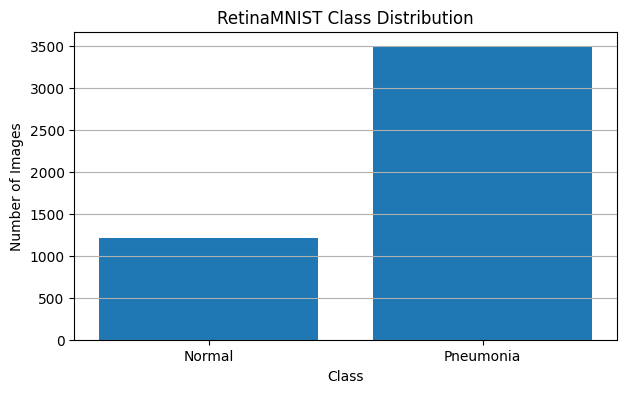


STEP 4: PREPROCESSING / STANDARDIZATION
Original Image Size : (28, 28)
Flattened Size      : 784
Pixel Range         : 0.0 to 1.0

STEP 5: DATA SPLIT
Training Samples   : 4708
Validation Samples : 524
Testing Samples    : 624

MLP Architecture
Input  : 784
Hidden : 128 - ReLU
Hidden : 64  - ReLU
Output : 2 - Softmax


In [13]:
X_train, y_train, X_val, y_val, X_test, y_test = load_data()
print("RETINAMNIST DATASET")
print("Total Images :", len(X_train) + len(X_val) + len(X_test))
print("Image Shape  :", X_train.shape[1:])
print("Classes      :", len(np.unique(y_train)))

show_eda(X_train, y_train)

X_train, X_val, X_test, y_train, y_val, y_test = preprocess(X_train, y_train,
                            X_val, y_val,X_test, y_test)

input_size = X_train.shape[1]
classes = len(np.unique(y_train))
print("\nMLP Architecture")
print("Input  :", input_size)
print("Hidden : 128 - ReLU")
print("Hidden : 64  - ReLU")
print("Output :", classes, "- Softmax")

In [14]:
models, histories, results = train_regularizers(X_train, y_train,X_val,
                                    y_val,X_test, y_test,input_size, classes)


Training: Baseline


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape         ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense (Dense)        │ (None, 128)          │    100,480 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_1 (Dense)      │ (None, 64)           │      8,256 │
├──────────────────────┼──────────────────────┼────────────┤
│ dropout (Dropout)    │ (None, 64)           │          0 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_2 (Dense)      │ (None, 2)            │        130 │
└──────────────────────┴──────────────────────┴────────────┘

 Total params: 108,866 (425.26 KB)

 Trainable params: 108,866 (425.26 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape         ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense_9 (Dense)      │ (None, 128)          │    100,480 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_10 (Dense)     │ (None, 64)           │      8,256 │
├──────────────────────┼──────────────────────┼────────────┤
│ dropout_3 (Dropout)  │ (None, 64)           │          0 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_11 (Dense)     │ (None, 2)            │        130 │
└──────────────────────┴──────────────────────┴────────────┘

 Total params: 108,866 (425.26 KB)

 Trainable params: 108,866 (425.26 KB)

 Non-trainable params: 0 (0.00 B)

Test Accuracy: 85.9 %


In [15]:
model, history, accuracy, loss = train_early_stopping(X_train, y_train,X_val,
                                    y_val,X_test, y_test,input_size, classes)


Training: Early Stopping


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape         ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense_12 (Dense)     │ (None, 128)          │    100,480 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_13 (Dense)     │ (None, 64)           │      8,256 │
├──────────────────────┼──────────────────────┼────────────┤
│ dropout_4 (Dropout)  │ (None, 64)           │          0 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_14 (Dense)     │ (None, 2)            │        130 │
└──────────────────────┴──────────────────────┴────────────┘

 Total params: 108,866 (425.26 KB)

 Trainable params: 108,866 (425.26 KB)

 Non-trainable params: 0 (0.00 B)

Test Accuracy: 83.81 %
Epochs Trained: 10


REGULARIZATION PERFORMANCE COMPARISON
     Technique  Accuracy (%)     Loss
      Baseline     81.250000 0.639903
            L1     82.852566 0.739470
            L2     84.455127 0.499697
       Dropout     85.897434 0.521406
Early Stopping     83.814102 0.514686


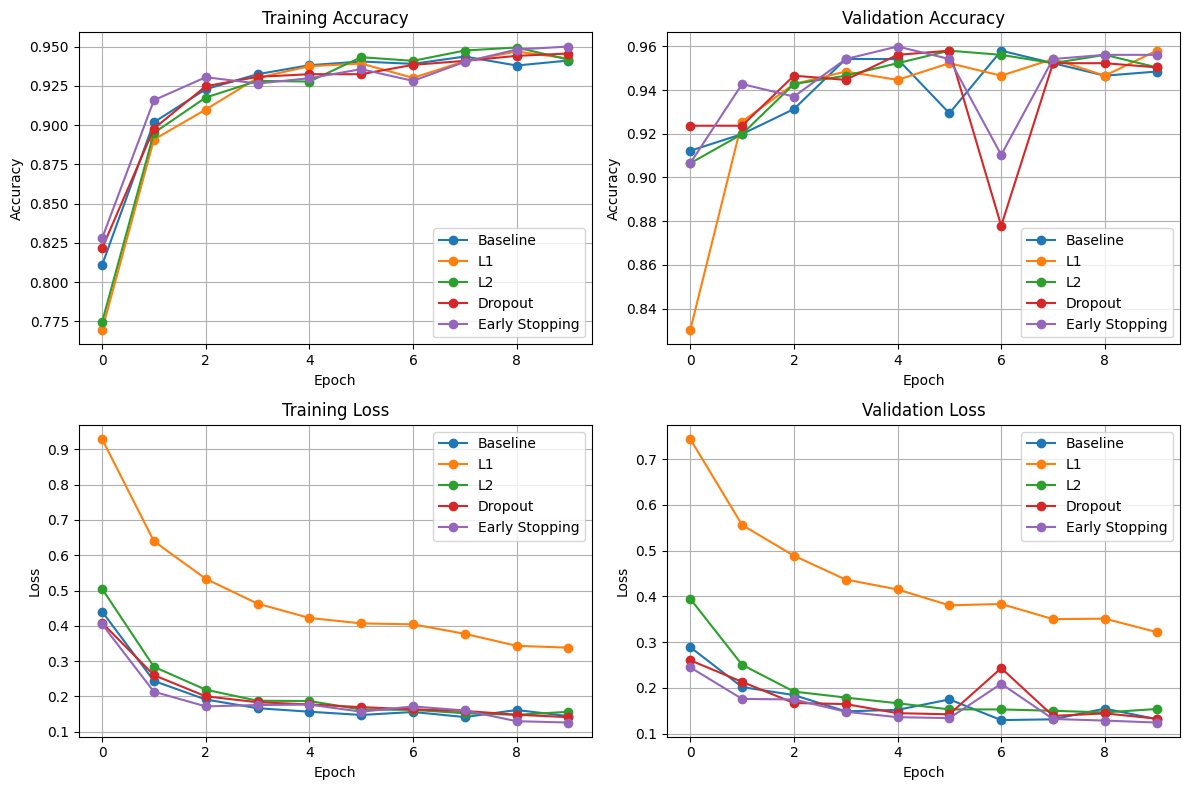

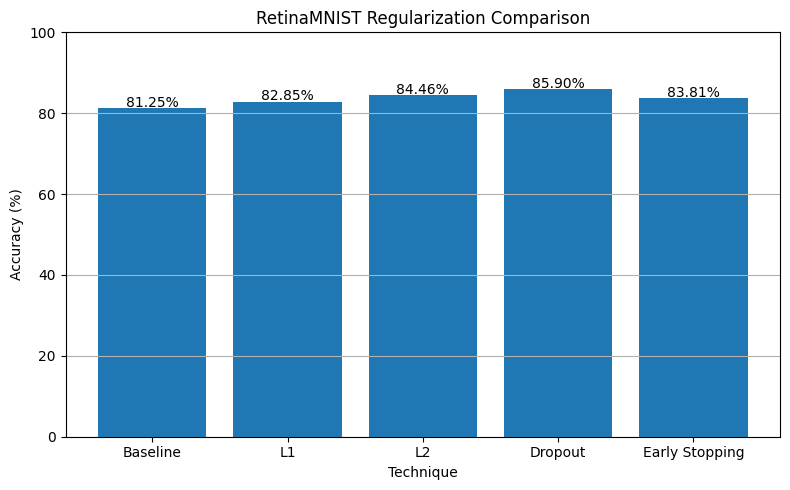


Dropout: 0.2 | L2: 0.0001 | LR: 0.001


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape         ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense_15 (Dense)     │ (None, 128)          │    100,480 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_16 (Dense)     │ (None, 64)           │      8,256 │
├──────────────────────┼──────────────────────┼────────────┤
│ dropout_5 (Dropout)  │ (None, 64)           │          0 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_17 (Dense)     │ (None, 2)            │        130 │
└──────────────────────┴──────────────────────┴────────────┘

 Total params: 108,866 (425.26 KB)

 Trainable params: 108,866 (425.26 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape         ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense_30 (Dense)     │ (None, 128)          │    100,480 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_31 (Dense)     │ (None, 64)           │      8,256 │
├──────────────────────┼──────────────────────┼────────────┤
│ dropout_10 (Dropout) │ (None, 64)           │          0 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_32 (Dense)     │ (None, 2)            │        130 │
└──────────────────────┴──────────────────────┴────────────┘

 Total params: 108,866 (425.26 KB)

 Trainable params: 108,866 (425.26 KB)

 Non-trainable params: 0 (0.00 B)

Accuracy: 84.94 %


In [16]:
models["Early Stopping"] = model
histories["Early Stopping"] = history
results.append(["Early Stopping", accuracy * 100, loss])
df = show_results(results)
plot_graphs(histories)
accuracy_graph(df)
tuning_df = hyperparameter_tuning(X_train, y_train,X_val,
                                  y_val,X_test, y_test,input_size, classes)



In [17]:
print("HYPERPARAMETER TUNING RESULTS")
print(tuning_df.to_string(index=False))
best = tuning_df.loc[tuning_df["Accuracy (%)"].idxmax()]
print("BEST HYPERPARAMETERS")
print("Dropout Rate :", best["Dropout"])
print("L2 Value     :", best["L2"])
print("Learning Rate:", best["Learning Rate"])
print("Best Accuracy:", round(best["Accuracy (%)"], 2), "%")

HYPERPARAMETER TUNING RESULTS
 Dropout     L2  Learning Rate  Accuracy (%)
     0.2 0.0001         0.0010     79.967946
     0.3 0.0001         0.0010     76.442307
     0.5 0.0001         0.0010     85.416669
     0.3 0.0010         0.0010     82.852566
     0.5 0.0010         0.0010     82.371795
     0.3 0.0010         0.0005     84.935898
BEST HYPERPARAMETERS
Dropout Rate : 0.5
L2 Value     : 0.0001
Learning Rate: 0.001
Best Accuracy: 85.42 %
